# 1. Imports & Config

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from lifelines import CoxPHFitter
from lifelines.statistics import proportional_hazard_test
from lifelines.utils import concordance_index
from sklearn.preprocessing import StandardScaler

DURATION_COL = 'duration'
EVENT_COL = 'event'
RANDOM_STATE = 42

# 2. Load Processed Data

In [18]:
train = pd.read_parquet('data/processed/train.parquet')
val   = pd.read_parquet('data/processed/val.parquet')
test  = pd.read_parquet('data/processed/test.parquet')

print(f"train: {train.shape} | val: {val.shape} | test: {test.shape}")

train: (463232, 37) | val: (420801, 37) | test: (1371471, 37)


# 3. FICO Averaging

In [19]:
for df in [train, val, test]:
    df['fico_score'] = (df['fico_range_low'] + df['fico_range_high']) / 2
    df.drop(columns=['fico_range_low', 'fico_range_high'], inplace=True)

print(train[['fico_score']].describe())

          fico_score
count  463232.000000
mean      698.180978
std        30.768783
min       627.000000
25%       677.000000
50%       692.000000
75%       712.000000
max       847.500000


# 4. Scale Numeric Features

In [20]:
feature_cols = [c for c in train.columns if c not in [DURATION_COL, EVENT_COL]]
numeric_cols = train[feature_cols].select_dtypes(include='number').columns.tolist()

scaler = StandardScaler()
train[numeric_cols] = scaler.fit_transform(train[numeric_cols])
val[numeric_cols]   = scaler.transform(val[numeric_cols])
test[numeric_cols]  = scaler.transform(test[numeric_cols])

print(train[numeric_cols].describe().loc[['mean', 'std']].round(3))

      loan_amnt  int_rate  installment  grade  sub_grade  emp_length  \
mean        0.0      -0.0         -0.0    0.0       -0.0         0.0   
std         1.0       1.0          1.0    1.0        1.0         1.0   

      annual_inc  dti  delinq_2yrs  open_acc  pub_rec  revol_bal  revol_util  \
mean        -0.0  0.0         -0.0       0.0     -0.0       -0.0        -0.0   
std          1.0  1.0          1.0       1.0      1.0        1.0         1.0   

      total_acc  term  fico_score  
mean       -0.0  -0.0        -0.0  
std         1.0   1.0         1.0  


# 5. Fit Cox PH Model

In [21]:
cph = CoxPHFitter(penalizer=0.1)
cph.fit(
    train,
    duration_col=DURATION_COL,
    event_col=EVENT_COL,
    show_progress=True
)

cph.print_summary()

Iteration 1: norm_delta = 2.60e-01, step_size = 0.9500, log_lik = -952808.31467, newton_decrement = 9.01e+03, seconds_since_start = 0.3
Iteration 2: norm_delta = 3.78e-02, step_size = 0.9500, log_lik = -944041.58034, newton_decrement = 7.43e+01, seconds_since_start = 0.5
Iteration 3: norm_delta = 2.50e-03, step_size = 0.9500, log_lik = -943966.79117, newton_decrement = 3.19e-01, seconds_since_start = 0.6
Iteration 4: norm_delta = 3.50e-06, step_size = 1.0000, log_lik = -943966.47154, newton_decrement = 6.11e-07, seconds_since_start = 0.8
Iteration 5: norm_delta = 1.10e-11, step_size = 1.0000, log_lik = -943966.47154, newton_decrement = 5.73e-18, seconds_since_start = 0.9
Convergence success after 5 iterations.


AttributeError: The '.style' accessor requires jinja2

<lifelines.CoxPHFitter: fitted with 463232 total observations, 387096 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 463232
number of events observed = 76136
   partial log-likelihood = -943966.47
         time fit was run = 2026-05-18 14:01:28 UTC

---
                                     coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                            
loan_amnt                            0.00      1.00      0.00           -0.00            0.01                1.00                1.01
int_rate                             0.12      1.13      0.00            0.12            0.13                1.12                1.14
installment                          0.02      1.02      0.00            0.01            0.02                1.01                1.02
grade                                0.11      1.11      0.00            0.10            0.11                1.10                1.12
sub_grade                            0.12      1.13      0.00            0.11            0.13                1.12                1.13
emp_length                          -0.01      0.99      0.00           -0.02           -0.01                0.98                0.99
annual_inc                          -0.07      0.93      0.00           -0.08           -0.07                0.92                0.94
dti                                  0.06      1.06      0.00            0.05            0.06                1.05                1.07
delinq_2yrs                         -0.01      0.99      0.00           -0.02           -0.00                0.98                1.00
open_acc                             0.02      1.02      0.00            0.02            0.03                1.02                1.03
pub_rec                              0.01      1.01      0.00            0.00            0.01                1.00                1.01
revol_bal                           -0.04      0.96      0.00           -0.05           -0.04                0.95                0.96
revol_util                          -0.03      0.97      0.00           -0.03           -0.02                0.97                0.98
total_acc                            0.01      1.01      0.00            0.00            0.01                1.00                1.01
term                                 0.02      1.02      0.00            0.01            0.02                1.01                1.03
home_ownership_OTHER                 0.09      1.09      0.14           -0.18            0.36                0.83                1.44
home_ownership_OWN                   0.03      1.03      0.01            0.01            0.05                1.01                1.06
home_ownership_RENT                  0.10      1.11      0.01            0.09            0.11                1.10                1.12
purpose_credit_card                 -0.05      0.95      0.01           -0.06           -0.03                0.94                0.97
purpose_debt_consolidation           0.04      1.04      0.01            0.03            0.05                1.03                1.06
purpose_educational                  0.12      1.13      0.11           -0.09            0.34                0.91                1.41
purpose_home_improvement            -0.02      0.98      0.01           -0.05            0.01                0.95                1.01
purpose_house                        0.05      1.05      0.04           -0.03            0.13                0.97                1.14
purpose_major_purchase              -0.04      0.96      0.02           -0.08            0.00                0.92                1.00
purpose_medical                      0.04      1.04      0.03           -0.02

# 6. Coefficient Plot

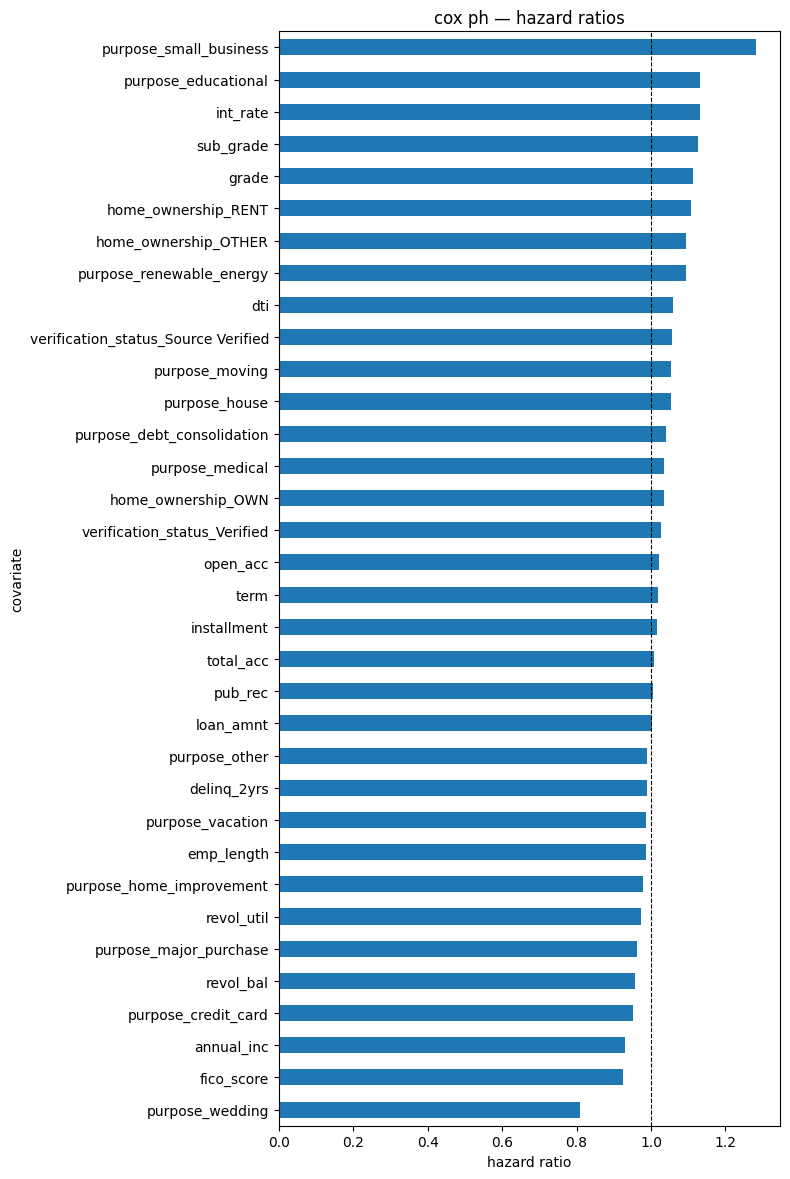

In [22]:
# Plot hazard ratios (exp of coefficients)
# Values > 1 increase default risk, values < 1 decrease it
coef = cph.params_.sort_values(ascending=True)
hazard_ratios = np.exp(coef)

fig, ax = plt.subplots(figsize=(8, len(coef) * 0.35))
hazard_ratios.plot(kind='barh', ax=ax)
ax.axvline(x=1, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('hazard ratio')
ax.set_title('cox ph — hazard ratios')
plt.tight_layout()
plt.show()

# 7. Proportional Hazards Assumption Check

In [23]:
# Schoenfeld residual test — p < 0.05 means the feature violates PH assumption
results = proportional_hazard_test(cph, train, time_transform='rank')
results.print_summary()

violations = results.summary[results.summary['p'] < 0.05].index.tolist()
print(f"features violating PH assumption: {violations}")

features violating PH assumption: ['annual_inc', 'dti', 'emp_length', 'fico_score', 'grade', 'home_ownership_RENT', 'int_rate', 'loan_amnt', 'open_acc', 'pub_rec', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_medical', 'purpose_moving', 'purpose_other', 'purpose_small_business', 'purpose_wedding', 'revol_bal', 'sub_grade', 'term', 'total_acc']


# 8. Survival Curves for Sample Borrowers

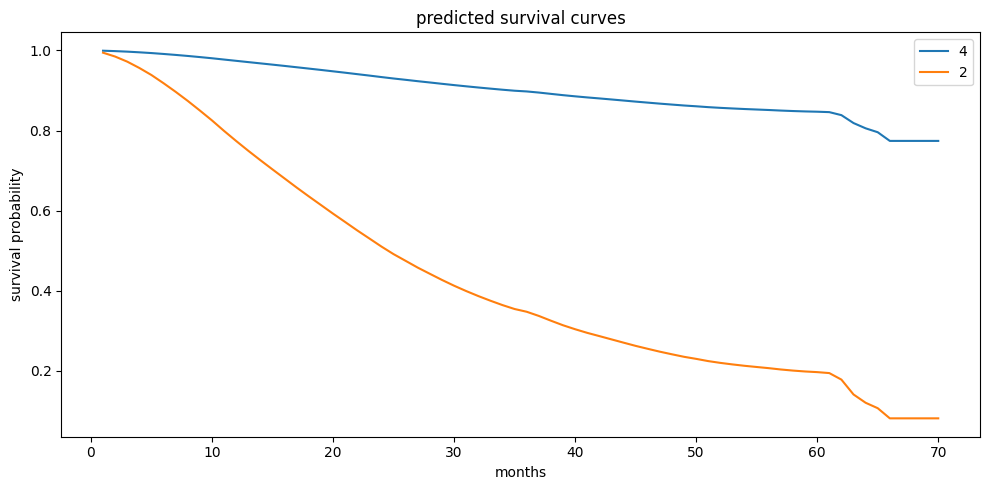

In [24]:
# Pick a high-risk and low-risk borrower from the test set based on grade
# grade is ordinal: 1=A (safest), 7=G (riskiest)
low_risk  = test[test['grade'] == test['grade'].min()].iloc[[0]]
high_risk = test[test['grade'] == test['grade'].max()].iloc[[0]]

fig, ax = plt.subplots(figsize=(10, 5))

cph.predict_survival_function(low_risk).plot(ax=ax, label='low risk (grade A)')
cph.predict_survival_function(high_risk).plot(ax=ax, label='high risk (grade G)')

ax.set_xlabel('months')
ax.set_ylabel('survival probability')
ax.set_title('predicted survival curves')
ax.legend()
plt.tight_layout()
plt.show()

# 9. Evaluation

In [ ]:
def evaluate(cph, df, label):
    # Predicted partial hazard — higher means more risk
    risk_scores = cph.predict_partial_hazard(df)
    c_stat = concordance_index(
        df[DURATION_COL],
        -risk_scores,  # negate so higher risk = lower expected survival time
        df[EVENT_COL]
    )
    print(f"{label} c-statistic: {c_stat:.4f}")
    return c_stat

evaluate(cph, val, 'val')
evaluate(cph, test, 'test')

val c-statistic: 0.6848
test c-statistic: 0.6931


np.float64(0.6930655785151761)

# 10. Brier Score

In [26]:
from lifelines.utils import survival_table_from_events

def brier_score(cph, df, label):
    # Evaluate at fixed time horizons
    horizons = [12, 24, 36]
    survival_probs = cph.predict_survival_function(df)

    for t in horizons:
        if t not in survival_probs.index:
            # find closest time point
            t = survival_probs.index[np.argmin(np.abs(survival_probs.index - t))]

        s_t = survival_probs.loc[t].values  # predicted S(t) for each borrower
        died_by_t = ((df[DURATION_COL] <= t) & (df[EVENT_COL] == 1)).astype(int).values

        bs = np.mean((s_t - (1 - died_by_t)) ** 2)
        print(f"{label} brier score at t={t}: {bs:.4f}")

brier_score(cph, val, 'val')
brier_score(cph, test, 'test')

val brier score at t=12: 0.0552
val brier score at t=24: 0.1093
val brier score at t=36: 0.1346
test brier score at t=12: 0.0442
test brier score at t=24: 0.0713
test brier score at t=36: 0.0865


# 11. Save Artifacts

In [ ]:
import json, os
os.makedirs('artifacts', exist_ok=True)

json.dump(
    {
        'numeric_cols': numeric_cols,
        'mean': scaler.mean_.tolist(),
        'std': scaler.scale_.tolist(),
        'feature_cols': feature_cols
    },
    open('artifacts/cox_scaler.json', 'w')
)

json.dump(
    {col: float(cph.params_[col]) for col in feature_cols},
    open('artifacts/cox_ph_coef.json', 'w')
)

baseline = cph.baseline_survival_
json.dump(
    {'times': baseline.index.tolist(), 'survival': baseline.iloc[:, 0].tolist()},
    open('artifacts/cox_ph_baseline.json', 'w')
)
print('cox artifacts saved')